Animação do movimento retilíneo uniforme

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

In [2]:
# Parâmetros do movimento retilíneo uniformemente variado (MRUV)
initial_position = 0.0  # Posição inicial (metros)
initial_velocity = 0.0  # Velocidade inicial (metros por segundo)
acceleration = 1.0      # Aceleração (metros por segundo ao quadrado)
time_duration = 10.0    # Duração total da animação (segundos)
num_frames = 200        # Número de quadros da animação

Agora, vamos calcular as posições do objeto ao longo do tempo e configurar a animação.

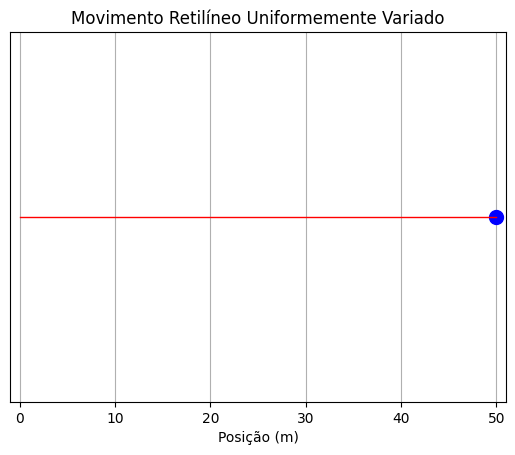

In [3]:
# Gerar o tempo e as posições
t = np.linspace(0, time_duration, num_frames)
# Fórmula do MRUV: x = x0 + v0*t + 0.5*a*t^2
x = initial_position + initial_velocity * t + 0.5 * acceleration * t**2

# Configurar a figura e o eixo
fig, ax = plt.subplots()
# Ajusta o limite X com base na posição inicial e final (pode ser negativo)
ax.set_xlim(min(x) - 1, max(x) + 1)
ax.set_ylim(-0.5, 0.5) # Um pequeno intervalo Y para o objeto
ax.set_xlabel('Posição (m)')
ax.set_title('Movimento Retilíneo Uniformemente Variado') # Updated title
ax.set_yticks([]) # Remover ticks do eixo Y
ax.grid(True)

# Desenhar o objeto (um ponto) e a linha de trajetória
line, = ax.plot([], [], 'o', color='blue', markersize=10) # Objeto
path, = ax.plot([], [], '-', color='red', linewidth=1) # Trajetória

# Função de inicialização da animação
def init():
    line.set_data([], [])
    path.set_data([], [])
    return line, path,

# Função de animação (o que acontece em cada quadro)
def animate(i):
    current_x = x[i]

    # matplotlib.lines.Line2D.set_data expects sequences (lists, arrays).
    # current_x is a scalar, so wrap it in a list along with y (0).
    line.set_data([current_x], [0]) # Atualiza a posição do objeto
    path.set_data(x[:i+1], np.zeros(i+1)) # Atualiza a trajetória percorrida

    return line, path,

# Criar a animação
ani = animation.FuncAnimation(
    fig, animate, init_func=init, frames=num_frames, interval=time_duration/num_frames * 1000, blit=True
)

# Para exibir a animação no Jupyter/Colab, é necessário um HTML/JS ou salvar como GIF/MP4
from IPython.display import HTML
HTML(ani.to_jshtml())

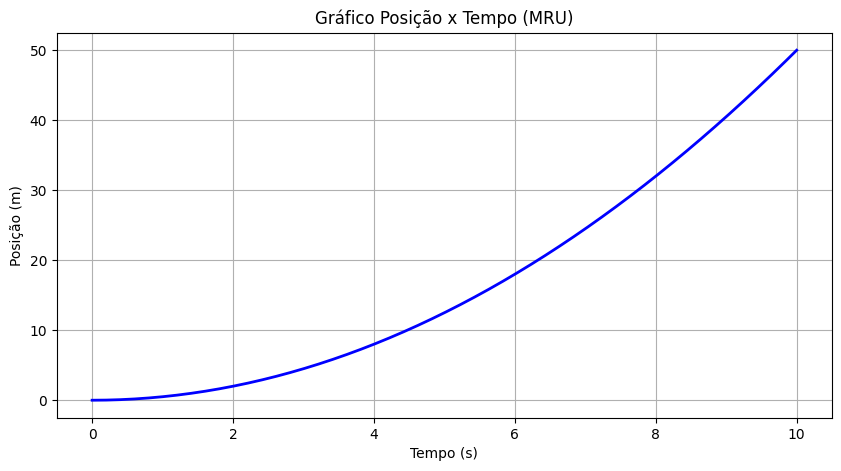

In [4]:
# Gráfico Posição x Tempo
plt.figure(figsize=(10, 5))
plt.plot(t, x, color='blue', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.title('Gráfico Posição x Tempo (MRU)')
plt.grid(True)
plt.show()

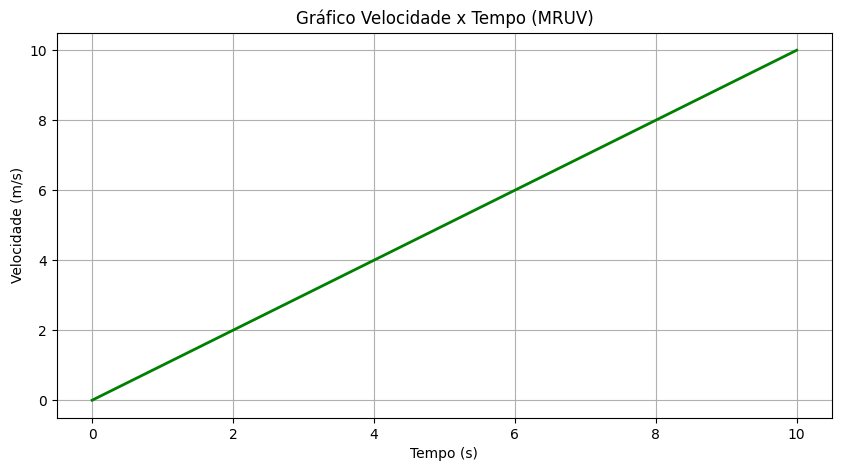

In [5]:
# Gráfico Velocidade x Tempo
# Fórmula do MRUV: v = v0 + a*t
v = initial_velocity + acceleration * t # Velocidade variada no MRUV
plt.figure(figsize=(10, 5))
plt.plot(t, v, color='green', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Gráfico Velocidade x Tempo (MRUV)') # Updated title
plt.grid(True)
plt.show()

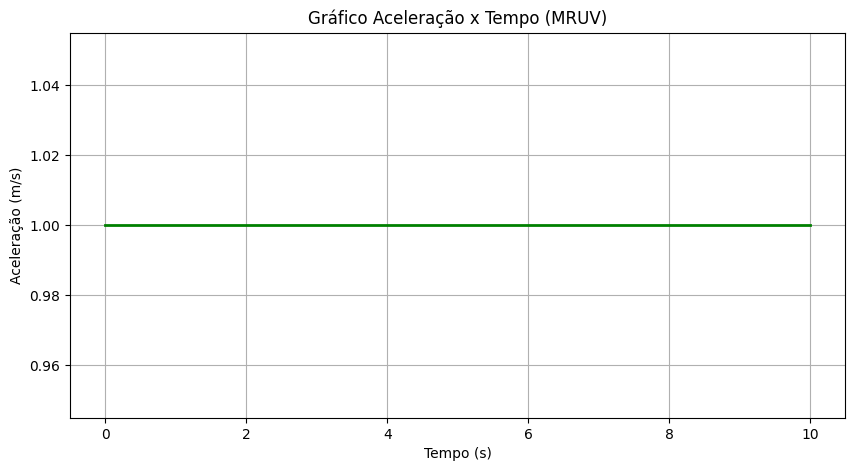

In [6]:
# Gráfico Aceleração x Tempo
# Fórmula do MRUV: a = constante
a = np.full_like(t, acceleration) # Aceleração constante
plt.figure(figsize=(10, 5))
plt.plot(t, a, color='green', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s)')
plt.title('Gráfico Aceleração x Tempo (MRUV)') # Updated title
plt.grid(True)
plt.show()

In [7]:
import pandas as pd

# Tabela Posição x Tempo
position_time_df = pd.DataFrame({
    'Tempo (s)': t,
    'Posição (m)': x
})
print("Tabela: Posição x Tempo")
display(position_time_df.head())

Tabela: Posição x Tempo


,Tempo (s),Posição (m)
0,0.000000,0.000000
1,0.050251,0.001263
2,0.100503,0.005050
3,0.150754,0.011363
4,0.201005,0.020202


In [9]:
# Tabela Velocidade x Tempo
velocity_time_df = pd.DataFrame({
    'Tempo (s)': t,
    'Velocidade (m/s)': v
})
print("\nTabela: Velocidade x Tempo")
display(velocity_time_df.head())


Tabela: Velocidade x Tempo


,Tempo (s),Velocidade (m/s)
0,0.000000,0.000000
1,0.050251,0.050251
2,0.100503,0.100503
3,0.150754,0.150754
4,0.201005,0.201005


In [10]:
# Tabela Aceleração x Tempo
acceleration_time_df = pd.DataFrame({
    'Tempo (s)': t,
    'Aceleração (m/s)': a
})
print("\nTabela: Aceleração x Tempo")
display(acceleration_time_df.head())


Tabela: Aceleração x Tempo


,Tempo (s),Aceleração (m/s)
0,0.000000,1.0
1,0.050251,1.0
2,0.100503,1.0
3,0.150754,1.0
4,0.201005,1.0
